In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_cust = pd.read_csv('customers.csv')   #data profile customer-8000 customers
df_ord = pd.read_csv('orders.csv')       #data order-25000 orders
df_month = pd.read_csv('monthly_revenue.csv') #data pendapatan bulanan,quartal,dan tahun
df_prod = pd.read_csv('product_summary.csv')  #data ttg produk yang dijual

In [3]:
pd.set_option('display.max_columns',None)  #biar display tabel nya full

In [4]:
df_cust

,customer_id,country,age,gender,membership_tier,registration_date,total_orders,total_spend_usd,avg_order_value_usd,days_since_last_purchase,preferred_category,preferred_device,preferred_payment_method,acquisition_channel,reviews_given,avg_review_score,returns_made,wishlist_items,newsletter_subscribed,churned
0,C00001,United States,40,Male,Free,2019-01-17,4,286.63,63.78,49,Food & Grocery,Mobile,Debit Card,Social Media,1,4.5,0,12,0,0
1,C00002,United States,20,Female,Free,2026-03-04,11,1245.18,107.32,126,Toys & Games,Mobile,Debit Card,Organic Search,2,2.6,1,1,0,0
2,C00003,United States,43,Female,Gold,2026-02-08,4,195.37,42.74,0,Home & Kitchen,Mobile,PayPal,Referral,0,4.8,0,0,1,0
3,C00004,United States,41,Male,Free,2025-03-19,6,99.45,15.61,6,Electronics,Desktop,PayPal,Organic Search,2,4.2,0,8,1,0
4,C00005,France,37,Other,Platinum,2024-09-10,36,2593.21,79.09,161,Clothing & Apparel,Tablet,Debit Card,Social Media,9,4.0,4,5,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,C07996,United States,36,Male,Gold,2025-07-09,13,1953.76,175.38,40,Jewelry & Accessories,Tablet,Debit Card,Social Media,1,4.4,1,14,1,1
7996,C07997,India,42,Male,Free,2025-06-28,31,6772.20,251.76,53,Electronics,Mobile,Credit Card,Paid Ad,12,4.6,4,1,0,0
7997,C07998,India,34,Male,Platinum,2026-02-01,46,2430.09,58.01,18,Home & Kitchen,Desktop,Cryptocurrency,Organic Search,9,4.2,6,0,1,0
7998,C07999,Japan,44,Female,Free,2026-01-15,35,5552.56,147.22,50,Food & Grocery,Mobile,Credit Card,Paid Ad,10,4.1,1,2,0,0


In [5]:
#pemahaman data(umum)
df_cust.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               8000 non-null   object 
 1   country                   8000 non-null   object 
 2   age                       8000 non-null   int64  
 3   gender                    8000 non-null   object 
 4   membership_tier           8000 non-null   object 
 5   registration_date         8000 non-null   object 
 6   total_orders              8000 non-null   int64  
 7   total_spend_usd           8000 non-null   float64
 8   avg_order_value_usd       8000 non-null   float64
 9   days_since_last_purchase  8000 non-null   int64  
 10  preferred_category        8000 non-null   object 
 11  preferred_device          8000 non-null   object 
 12  preferred_payment_method  8000 non-null   object 
 13  acquisition_channel       8000 non-null   object 
 14  reviews_

In [6]:
#deskripsi statistik
df_cust.describe()

,age,total_orders,total_spend_usd,avg_order_value_usd,days_since_last_purchase,reviews_given,avg_review_score,returns_made,wishlist_items,newsletter_subscribed,churned
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,35.616375,16.545250,1558.642350,94.845566,59.583875,3.228750,4.109112,0.849500,4.457125,0.617375,0.089375
std,11.170455,14.681064,2284.094953,78.992885,60.610355,3.942698,0.523992,1.407337,4.854391,0.486058,0.285302
min,18.000000,1.000000,4.890000,5.000000,0.000000,0.000000,1.800000,0.000000,0.000000,0.000000,0.000000
25%,27.000000,5.000000,336.055000,44.690000,16.000000,0.000000,3.800000,0.000000,1.000000,0.000000,0.000000
50%,35.000000,12.000000,845.700000,72.270000,41.000000,2.000000,4.200000,0.000000,3.000000,1.000000,0.000000
75%,43.000000,23.000000,1892.165000,118.560000,84.000000,5.000000,4.500000,1.000000,6.000000,1.000000,0.000000
max,75.000000,79.000000,61282.480000,1051.730000,582.000000,28.000000,5.000000,11.000000,41.000000,1.000000,1.000000


In [7]:
#handling missing dan dupicate values
df_cust.isnull().sum()

customer_id                 0
country                     0
age                         0
gender                      0
membership_tier             0
registration_date           0
total_orders                0
total_spend_usd             0
avg_order_value_usd         0
days_since_last_purchase    0
preferred_category          0
preferred_device            0
preferred_payment_method    0
acquisition_channel         0
reviews_given               0
avg_review_score            0
returns_made                0
wishlist_items              0
newsletter_subscribed       0
churned                     0
dtype: int64

In [8]:
df_cust.duplicated().sum()

np.int64(0)

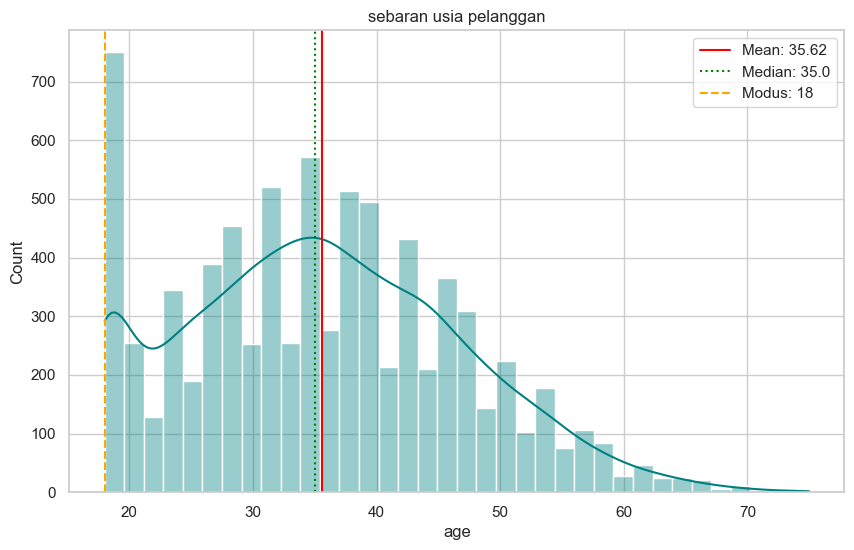

In [9]:
##segmentasi pelanggan 
mean = df_cust['age'].mean()
modus = df_cust['age'].mode()[0]
median = df_cust['age'].median()

sns.set_theme(style="whitegrid") 
plt.figure(figsize=(10, 6))

sns.histplot(data=df_cust, x='age', kde=True, color="teal", alpha=0.4)

plt.axvline(mean, color='red', linestyle='solid', label=f'Mean: {mean:.2f}')
plt.axvline(median, color='green', linestyle=':', label=f'Median: {median}')
plt.axvline(modus, color='orange', linestyle='dashed', label=f'Modus: {modus}')

plt.title('sebaran usia pelanggan')
plt.legend();

dapat dilihat ada dua sumbu yang menonjol,daerah modus dan juga rata-rata.
di bagian modus ternyata penggunan didominasi oleh anak muda,hal ini menunjukkan hits(lonjakan) terhadap sektor e-commerce atau kita sebut belanja online

di bagian rata-rata umumnya orang berusia 35-37 tahun(dalam usia produktif/bekerja) menjadi pengguna platform e-commerce

semakin ke kanan jumlah pengguna di usia lebih dari 37 tahun cenderung menurun,artinya produk atau pemasaran dalam sistem e-commerce kurang relevan bagi kelompok itu

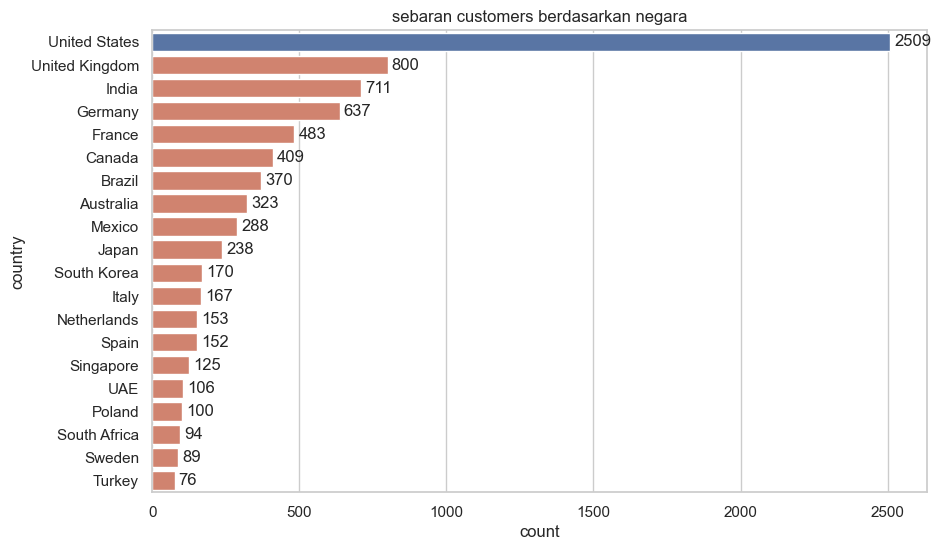

In [10]:
sns.set_theme(style="whitegrid") 
plt.figure(figsize=(10, 6))

df_counts = df_cust['country'].value_counts().reset_index()
df_counts.columns = ['country', 'count']

color = ['#E07A5F' if i != 'United States' else '#4C72B0' for i in df_counts['country']]

ax = sns.barplot(data=df_counts, x='count', y='country', palette=color,hue='country',legend=False)
for containers in ax.containers:
    ax.bar_label(containers,padding=3)
    
plt.title('sebaran customers berdasarkan negara');



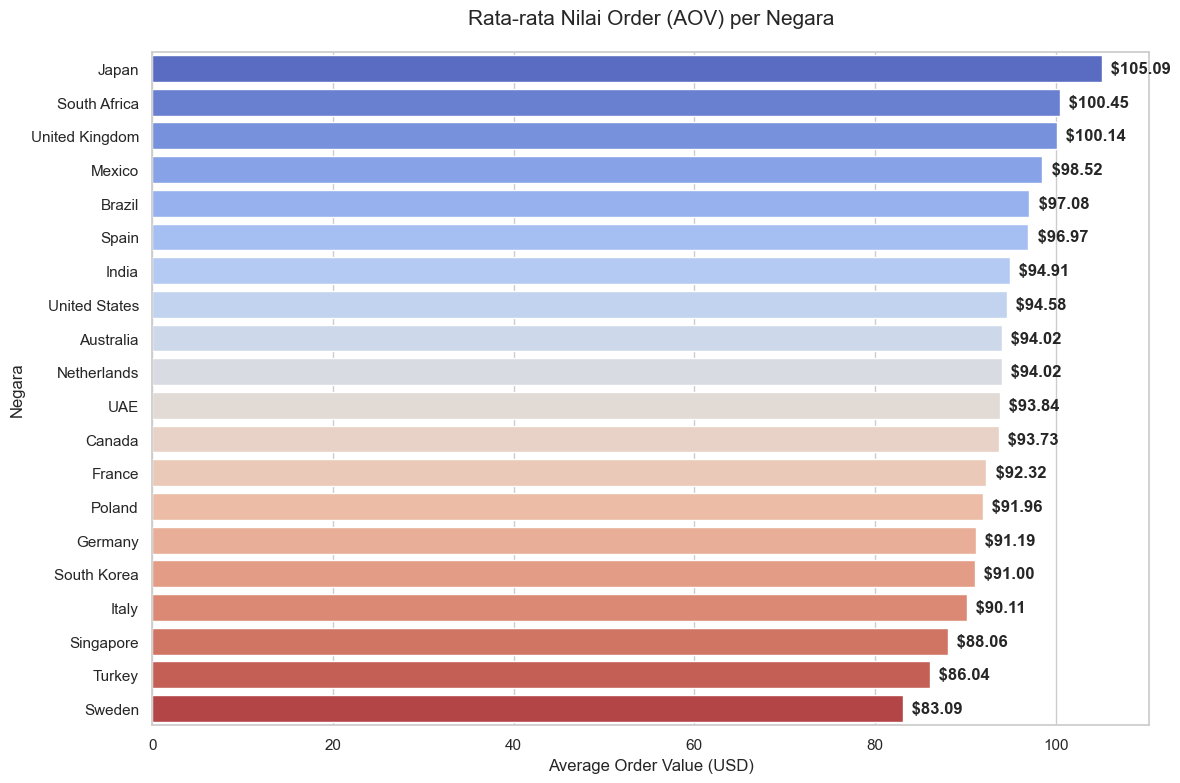

In [11]:
df_country_aov = df_cust.groupby('country')['avg_order_value_usd'].mean().sort_values(ascending=False).reset_index()
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=df_country_aov, 
    x='avg_order_value_usd', 
    y='country', 
    hue='country', 
    palette='coolwarm', 
    legend=False)

for container in ax.containers:
    ax.bar_label(container, fmt=' $%.2f', padding=3, fontweight='bold')

plt.title('Rata-rata Nilai Order (AOV) per Negara', fontsize=15, pad=20)
plt.xlabel('Average Order Value (USD)')
plt.ylabel('Negara')
plt.tight_layout();

walaupun usernya kebanyakan bersal dari eropa ternyata pembeli tertinggi berasal dari jepang

1. United States: "Si Raksasa yang Stabil" Data: US punya user terbanyak (2.509), tapi AOV-nya ada di posisi tengah ($94.58).

pasar dari US cenderung cukup dimana memiliki user terbanyak dengan AOV yang menengah keatas yang berarti daya belinya cukup untuk menyaingi jumlah usernya

2. Japan: "Pasar Premium/Potensial" dilihat dari visualisasi data, jepang punya AOV tertinggi ($105.09), padahal jumlah user-nya tidak masuk 5 besar (hanya 238 user).

Pelanggan Jepang ini adalah tipe High-Spender. Meskipun jumlahnya lebih sedikit dibanding US atau UK, sekali belanja mereka mengeluarkan uang paling banyak.

3. Germany: "Efisien tapi Hemat" dari data, jerman masuk 5 besar user terbanyak (637 user), tapi AOV-nya paling rendah ($91.19).

Orang Jerman banyak yang beli, tapi mereka sangat perhitungan atau mungkin hanya beli barang-barang esensial/murah.

4. India & UK: "The Sweet Spot"Data: Keduanya punya jumlah user banyak (UK: 800, India: 711) dan aov yang cukup tinggi (UK: $100.14, India: $94.91).
Ini adalah pasar paling sehat setelah US. Mereka punya keseimbangan antara jumlah massa dan daya beli yang kuat dan ada kemungkinan untuk ekspansi di wilayah ini

In [12]:
summary = df_cust.groupby('membership_tier')['total_spend_usd'].agg(['mean','median','sum','count'])
summary

,mean,median,sum,count
membership_tier,,,,
Free,1393.208067,775.01,6190023.44,4443
Gold,1863.585930,1006.85,2193440.64,1177
Platinum,2600.637112,1425.95,1674810.30,644
Silver,1388.746786,785.01,2410864.42,1736


<Axes: title={'center': 'Sebaran Member'}, ylabel='count'>

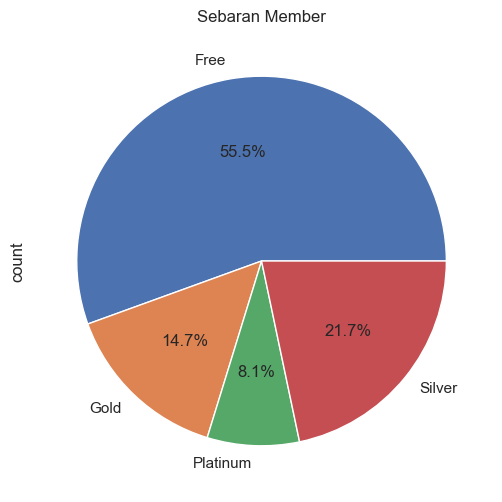

In [13]:
summary['count'].plot(kind='pie', autopct='%1.1f%%', figsize=(6, 6), title='Sebaran Member')

1. Performa Platinum

Meskipun jumlah anggotanya paling sedikit (644), rata-rata pengeluaran mereka (Mean: $2,600) jauh melampaui tier lainnya.
Seorang member Platinum bernilai hampir 2x lipat dari member Silver/Free. Dengan kata lain layanan sistem e-commerce ini berhasil mendorong pengeluaran yang lebih tinggi.

2. Tier Silver vs Free

Rata-rata belanja member Silver ($1,388) justru sedikit lebih rendah dari member Free ($1,393). Dari sisi spending seorang member free bisa lebih banyak dari member silver,dapat dilihat bahwa program yang ditawarkan perlu untuk dievaluasi untuk mendorong spending khususnya user member silver

3. Kontributor Pendapatan Terbesar 
Walaupun secara individual member free tidak mendapat layanan atau fitur yang ditawarkan tetapi dari segi spending per orang cukup mengejutkan, mereka adalah penyumbang total uang terbanyak ($6.19 Juta) dengan rata-rata spending $1,393 yang didukung jumlah mereka yang masif (4.443 orang atau 55.5% dari total seluruh user).

C:\Users\HP\AppData\Local\Temp\ipykernel_5068\2323812157.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x='total_spend_usd',y='membership_tier',data=df_cust,order=tier ,palette='magma',


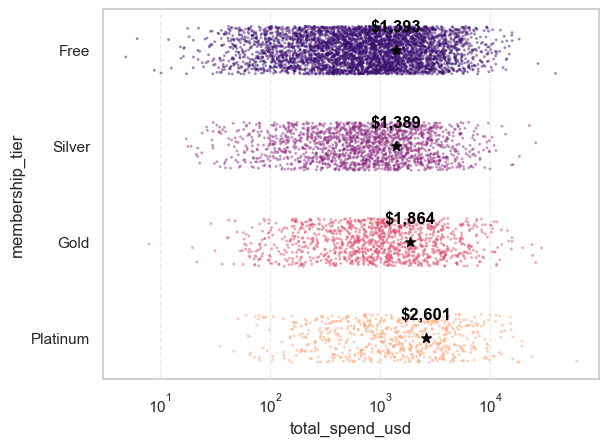

In [14]:
df_cust['membership_tier'].unique()

tier = ['Free', 'Silver', 'Gold', 'Platinum']

sns.stripplot(x='total_spend_usd',y='membership_tier',data=df_cust,order=tier ,palette='magma',
    alpha=0.5,         # transparansi agar tumpukan data terlihat
    jitter=0.25,       # lebar sebaran titik secara vertikal
    size=2)

mean_values = summary.loc[tier, 'mean']

for i, m_val in enumerate(mean_values):
    plt.scatter(x=m_val, y=i, color='black', marker='*', s=50, zorder=5, label='Mean' if i == 0 else "")
    plt.text(x=m_val,y= i - 0.2, s=f'${m_val:,.0f}', color='black', fontweight='bold', ha='center')


plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.xscale('log')
#sebaran membership sama totl spendnya

lanjutan

1. Bukti "The Power of High Spenders"
(Ekor Kanan)Lihat titik-titik yang menyebar ke arah kanan (melewati angka $10k).Di semua tier, ada pelanggan yang belanjanya tembus angka puluhan ribu dolar.Inilah alasan kenapa Mean (bintang hitam) jauh lebih tinggi daripada kumpulan titik terpadat. Para "Whales" ini yang narik rata-rata ke kanan.

2. Kepadatan Silver vs Free

Secara visual, awan titik di tier Free jauh lebih padat dan lebar daripada Silver.Ini mengonfirmasi temuan sebelumnya: Member Free punya jumlah massa yang masif, dan secara kolektif mereka sangat kuat dalam menyumbang revenue meskipun "gratisan".
 
3. Large spending tier Platinum

Perhatikan kerumunan di sisi kanan mean di tier Platinum. Titik-titiknya lebih bergeser ke arah kanan dibanding tier lainnya.Ini artinya bukan cuma satu-dua orang yang belanja besar, tapi secara sistematis, standar belanja member Platinum memang lebih tinggi.
 
4. Overlap yang Luas

Ada overlap besar antara semua tier. Artinya, banyak member Free yang belanjanya sebenarnya setara atau bahkan lebih banyak daripada member Gold

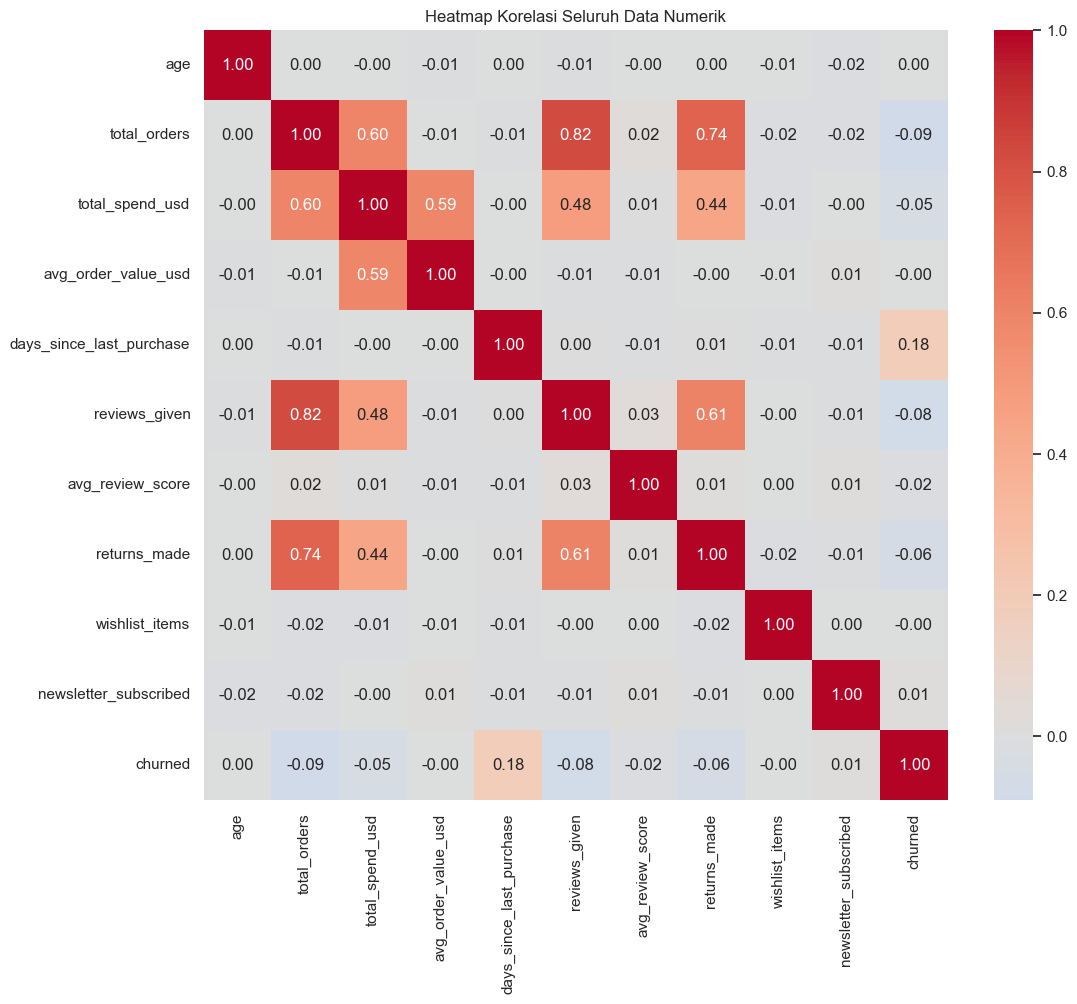

In [15]:
df_numerik = df_cust.select_dtypes(include=['number'])


corr_matrix = df_numerik.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt=".2f", 
            cmap='coolwarm', 
            center=0)

plt.title('Heatmap Korelasi Seluruh Data Numerik')
plt.show()


1. Reviews dan Total Orders (0.82).Ini korelasi tertinggi di data customer. Semakin sering orang belanja, semakin rajin mereka kasih review.dapat diartikan review bukan cuma soal kepuasan, tapi soal engagement selain itu dapat menjadi preview untuk kustomer baru.

3. Sisi Gelap: Returns vs Total Orders (0.74)Ada hubungan positif yang kuat antara jumlah order dan jumlah retur (pengembalian barang).Artinya: Semakin banyak orang belanja, risiko retur makin tinggi.Ini dapat jadi variabel krusia untuk para tim memberikan layanan pesanan yang optimal

3. Wishlist & Newsletter (0.00) Korelasi wishlist_items dan newsletter_subscribed terhadap total_spend_usd hampir NOL.Artinya: Di dataset ini, orang yang masukin barang ke wishlist atau langganan email tidak otomatis belanja lebih banyak. Strategi wishlist ini mungkin perlu diperbaiki agar benar-benar mendorong konversi untuk menjadi pembelian.

In [16]:
df_ord
###segi order,kategori produk mana yang  hasilin ratingnya ascending sama revenuenya,###

,order_id,customer_id,order_date,year,month,quarter,day_of_week,product_name,category,unit_price_usd,quantity,subtotal_usd,discount_pct,discount_amount_usd,shipping_fee_usd,tax_pct,tax_amount_usd,total_amount_usd,payment_method,device_used,delivery_days,delivery_date,order_status,returned,customer_rating,session_duration_minutes,pages_viewed_before_purchase,is_repeat_customer
0,O000001,C07108,2020-08-27,2020,8,Q3,Thursday,Tire Inflator,Automotive,62.91,1,62.91,0,0.00,0.00,18,11.32,74.23,Credit Card,Desktop,3,2020-08-30,Delivered,0,NaN,14.4,1,1
1,O000002,C03487,2024-04-11,2024,4,Q2,Thursday,Stud Earrings Gold,Jewelry & Accessories,18.44,1,18.44,0,0.00,3.99,10,1.84,24.27,Credit Card,Mobile,2,2024-04-13,Delivered,0,NaN,9.0,4,0
2,O000003,C03062,2023-06-25,2023,6,Q2,Sunday,Pen Set Premium,Office Supplies,109.79,1,109.79,20,21.96,0.00,8,7.03,94.86,PayPal,Desktop,3,2023-06-28,Delivered,0,4.0,3.2,17,0
3,O000004,C00888,2020-08-16,2020,8,Q3,Sunday,Smart Watch Series 5,Electronics,87.21,1,87.21,50,43.60,0.00,8,3.49,47.10,Credit Card,Tablet,2,2020-08-18,Returned,1,NaN,32.2,3,1
4,O000005,C01674,2020-04-24,2020,4,Q2,Friday,Stud Earrings Gold,Jewelry & Accessories,94.30,2,188.60,0,0.00,9.99,5,9.43,208.02,Debit Card,Mobile,5,2020-04-29,Delivered,0,2.8,54.7,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,O024996,C07416,2023-03-15,2023,3,Q1,Wednesday,Sports Socks 6-Pack,Clothing & Apparel,59.18,1,59.18,15,8.88,0.00,0,0.00,50.30,Credit Card,Mobile,4,2023-03-19,Delivered,0,NaN,7.9,7,1
24996,O024997,C04387,2024-04-22,2024,4,Q2,Monday,Shower Curtain,Home & Kitchen,81.17,5,405.85,0,0.00,9.99,8,32.47,448.31,Cryptocurrency,Desktop,4,2024-04-26,Delivered,0,NaN,134.7,16,1
24997,O024998,C07566,2023-06-07,2023,6,Q2,Wednesday,Collagen Peptides,Health & Wellness,28.92,5,144.60,0,0.00,6.99,18,26.03,177.62,Credit Card,Desktop,5,2023-06-12,Delivered,0,4.6,4.2,16,1
24998,O024999,C04986,2024-05-06,2024,5,Q2,Monday,Energy Bars 12-Pack,Food & Grocery,19.43,2,38.86,0,0.00,0.00,8,3.11,41.97,Credit Card,Mobile,4,2024-05-10,Delivered,0,4.3,13.5,9,1


In [17]:
df_ord.info()#terdapat NaN values yang cukup banyak di kolom customer_rating 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   order_id                      25000 non-null  object 
 1   customer_id                   25000 non-null  object 
 2   order_date                    25000 non-null  object 
 3   year                          25000 non-null  int64  
 4   month                         25000 non-null  int64  
 5   quarter                       25000 non-null  object 
 6   day_of_week                   25000 non-null  object 
 7   product_name                  25000 non-null  object 
 8   category                      25000 non-null  object 
 9   unit_price_usd                25000 non-null  float64
 10  quantity                      25000 non-null  int64  
 11  subtotal_usd                  25000 non-null  float64
 12  discount_pct                  25000 non-null  int64  
 13  d

In [18]:
df_ord.isnull().sum()

order_id                            0
customer_id                         0
order_date                          0
year                                0
month                               0
quarter                             0
day_of_week                         0
product_name                        0
category                            0
unit_price_usd                      0
quantity                            0
subtotal_usd                        0
discount_pct                        0
discount_amount_usd                 0
shipping_fee_usd                    0
tax_pct                             0
tax_amount_usd                      0
total_amount_usd                    0
payment_method                      0
device_used                         0
delivery_days                       0
delivery_date                       0
order_status                        0
returned                            0
customer_rating                 15749
session_duration_minutes            0
pages_viewed

In [19]:
df_ord['customer_rating'].fillna(df_ord['customer_rating'].mean(), inplace=True) ## mengisi missing values

C:\Users\HP\AppData\Local\Temp\ipykernel_5068\1069896486.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_ord['customer_rating'].fillna(df_ord['customer_rating'].mean(), inplace=True) ## mengisi missing values


In [20]:
df_ord.describe()

,year,month,unit_price_usd,quantity,subtotal_usd,discount_pct,discount_amount_usd,shipping_fee_usd,tax_pct,tax_amount_usd,total_amount_usd,delivery_days,returned,customer_rating,session_duration_minutes,pages_viewed_before_purchase,is_repeat_customer
count,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.00000,25000.000000
mean,2022.652840,6.352280,68.124030,1.695520,116.187322,5.630000,6.345500,3.867579,10.677080,11.746785,125.456186,4.179480,0.080800,4.002324,16.780432,6.51256,0.645960
std,1.814996,3.514614,57.258933,1.045436,136.994998,9.740785,17.530764,3.269618,6.504922,17.723056,145.635016,2.548507,0.272533,0.351333,15.811830,5.26557,0.478231
min,2020.000000,1.000000,3.360000,1.000000,3.360000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,1.000000,0.000000,1.500000,0.300000,1.00000,0.000000
25%,2021.000000,3.000000,29.250000,1.000000,38.467500,0.000000,0.000000,0.000000,8.000000,2.300000,43.450000,3.000000,0.000000,4.002324,7.100000,2.00000,0.000000
50%,2023.000000,6.000000,51.530000,1.000000,72.390000,0.000000,0.000000,3.990000,10.000000,6.220000,78.775000,4.000000,0.000000,4.002324,12.100000,5.00000,1.000000
75%,2024.000000,9.000000,87.877500,2.000000,140.160000,10.000000,5.250000,6.990000,18.000000,13.990000,149.872500,5.000000,0.000000,4.002324,21.100000,9.00000,1.000000
max,2026.000000,12.000000,697.030000,5.000000,2636.450000,50.000000,421.580000,9.990000,20.000000,303.990000,2730.880000,14.000000,1.000000,5.000000,361.200000,24.00000,1.000000


In [21]:
# Menghitung skewness AOV per Quarter
skew_per_quarter = df_month.groupby(['year','quarter'])['avg_order_value'].skew().reset_index()
skew_per_quarter.columns = ['tahun','quarter', 'aov_skewness']

print(skew_per_quarter)


    tahun quarter  aov_skewness
0    2020      Q1      1.385261
1    2020      Q2      1.665057
2    2020      Q3      1.405533
3    2020      Q4     -1.717014
4    2021      Q1     -0.676351
5    2021      Q2      1.298202
6    2021      Q3      0.042993
7    2021      Q4      0.737850
8    2022      Q1     -1.632677
9    2022      Q2      0.921287
10   2022      Q3      1.149235
11   2022      Q4      0.710872
12   2023      Q1      0.518137
13   2023      Q2      0.628481
14   2023      Q3     -0.613478
15   2023      Q4     -0.986763
16   2024      Q1      0.202907
17   2024      Q2      0.765236
18   2024      Q3     -1.024366
19   2024      Q4      0.404681
20   2025      Q1     -1.719232
21   2025      Q2     -0.045763
22   2025      Q3      0.759753
23   2025      Q4     -0.305171
24   2026      Q1     -0.852811


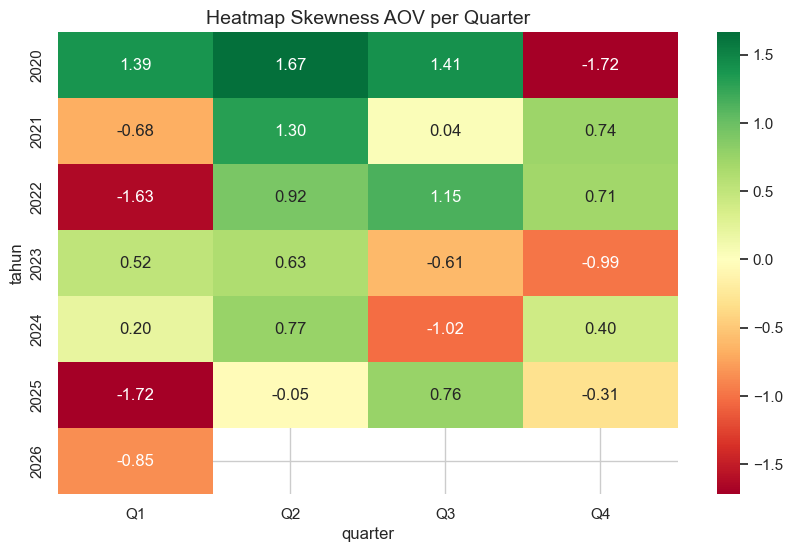

In [22]:
pivot_skew = skew_per_quarter.pivot(index="tahun", columns="quarter", values="aov_skewness")

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_skew, annot=True, cmap='RdYlGn', center=0, fmt=".2f")

plt.title('Heatmap Skewness AOV per Quarter', fontsize=14);

1. Dominasi Hijau : "transaksi kecil" 5-6 tahun kebelakang, pembelian/order masih dalam mayoritas transaksinya kecil tapi ada sedikit orang yang belanja dalam jumlah sangat besar.
   
2. Kemunculan Warna Merah (Skewness Negatif): "belanja borongan" dapat dilihat di 2020-Q4 (-1.72), 2022-Q1 (-1.63), 2025-Q1 (-1.72)berarti mayoritas pelanggan justru belanja dalam jumlah besar/mahal, dan sedikit sekali yang belanja receh.Kondisi Bisnis: Q4 2020 kemungkinan besar dipicu oleh Holiday Season (belanja besar buat kado). Untuk 2025-Q1, ini menunjukkan pergeseran permanen dimana pelanggan  makin royal atau cenderung meningkat dari segi transaksi dan itu sering terjadi dalam 9 bln sesudahnya(walaupun tidak terlalu masif)

3. Insight Data Terbaru (2026-Q1: -0.85) Awal tahun ini dimulai dengan tren negatif. Artinya, tren "belanja borongan" dari tahun 2025 masih berlanjut. Pelanggan di kuartal ini cenderung belanja di atas rata-rata tahun-tahun awal (2020).

Kesimpulan, walaupun perilaku belanja pelangganper quartal tidak konsisten secara musiman. Pergeseran dari hijau (2020) ke banyak warna merah/oranye (2023-2026) menunjukkan bahwa kualitas belanja (nilai per transaksi) meningkat seiring berjalannya waktu.

In [23]:
df_month

,year,month,quarter,orders,revenue_usd,avg_order_value,avg_discount_pct,return_rate,unique_customers,new_customers
0,2020,1,Q1,266,35415.25,133.14,5.68,0.0,261,100
1,2020,2,Q1,268,34304.78,128.00,6.06,0.0,263,93
2,2020,3,Q1,258,32642.23,126.52,5.21,0.0,254,81
3,2020,4,Q2,281,34865.39,124.08,5.27,0.0,275,99
4,2020,5,Q2,286,38625.73,135.06,5.84,0.0,282,113
...,...,...,...,...,...,...,...,...,...,...
70,2025,11,Q4,240,28149.83,117.29,5.00,0.0,240,80
71,2025,12,Q4,304,39321.84,129.35,5.64,0.0,298,107
72,2026,1,Q1,316,44793.18,141.75,5.62,0.0,309,100
73,2026,2,Q1,254,38488.48,151.53,5.59,0.0,251,87


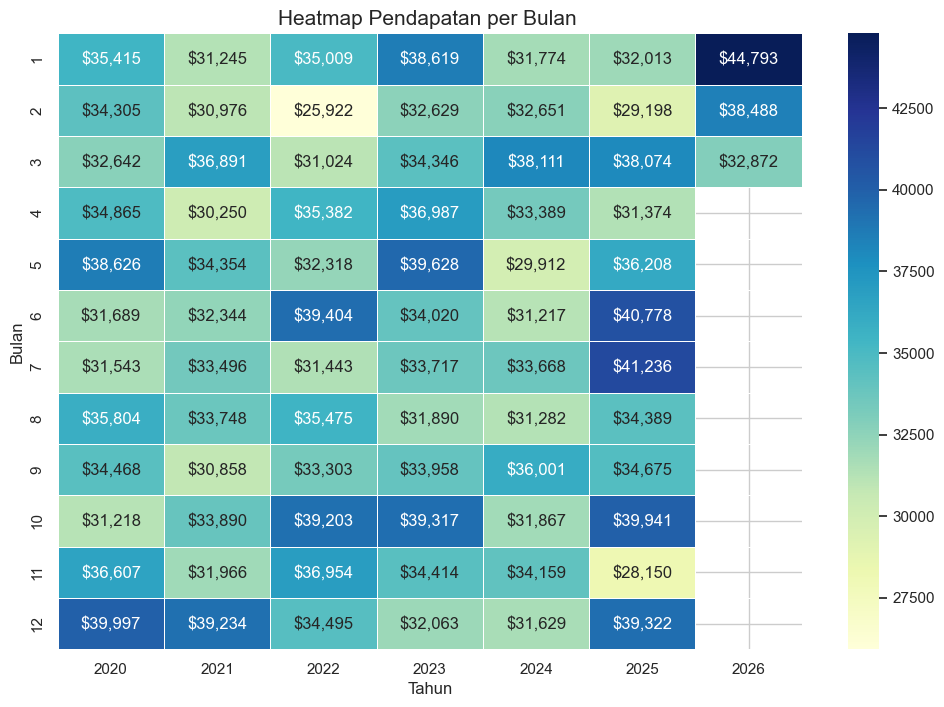

In [24]:
pivot_df = df_month.pivot_table(index='month', 
                          columns='year', 
                          values='revenue_usd')

labels = pivot_df.map("${:,.0f}".format)
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_df, 
            annot=labels,  
            fmt="",
            cmap="YlGnBu",    
            linewidths=.5)   

plt.title('Heatmap Pendapatan per Bulan ', fontsize=15)
plt.ylabel('Bulan')
plt.xlabel('Tahun');

1. Tren Pertumbuhan Tahunan yang Positif dapat lihat per baris (bulan yang sama), warna biru gelapnya makin sering muncul di tahun-tahun terbaru (2024-2025).Contoh: Di bulan Januari, pendapatan naik dari $35k (2020) menjadi $44k (2025). Ini menunjukkan skala bisnis ini terus membesar.

2. Tahun 2025: Tahun "Emas" Tahun 2025 punya kepadatan warna biru paling tinggi.Puncak Terbesar: Rekor pendapatan tertinggi ada di Januari 2025 ($44,793). Bisnis ini dapat mencapai efisiensi tertinggi di tahun ini dengan performa yang stabil di atas $35k hampir setiap bulan.

3. Titik Terendah (Low Point) Pendapatan terendah terjadi di Februari 2022 ($25,922).

4. Prediksi Awal 2026Insight: Data 2026 baru ada 3 bulan, tapi angkanya sudah sangat kompetitif ($44k, $38k, $32k).Analisis: Januari 2026 hampir menyamai rekor tertinggi Januari 2025. Ini sinyal bagus bahwa tahun ini punya potensi untuk memecahkan rekor tahun lalu jika trennya dijaga.

Text(0.5, 1.0, 'Rata-Rata Average Order Value (AOV) per quartal')

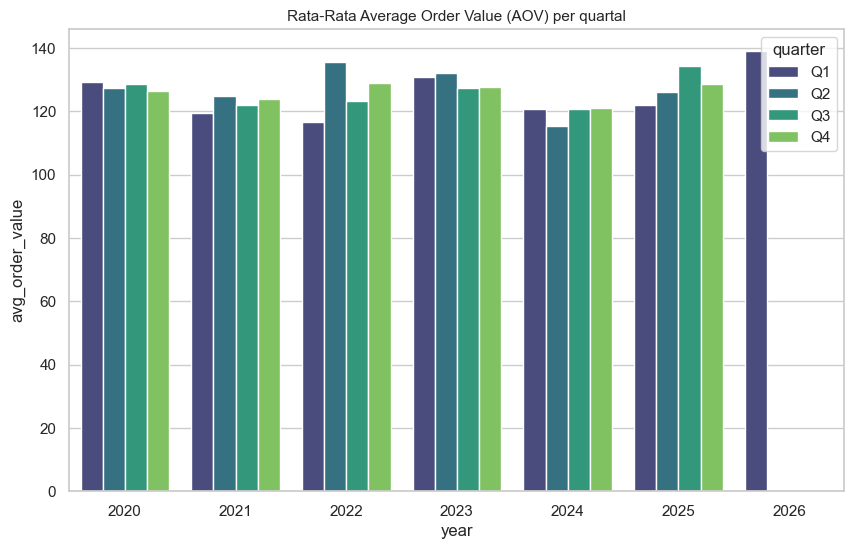

In [25]:
aov_year = df_month.groupby(['year','quarter'])['avg_order_value'].mean().reset_index()

sns.set_theme(style="whitegrid")

# 3. Buat visualisasi
plt.figure(figsize=(10, 6))
plot = sns.barplot(
    data=aov_year, 
    x='year', 
    y='avg_order_value', 
    hue='quarter',
    palette='viridis')
plt.title('Rata-Rata Average Order Value (AOV) per quartal', fontsize=11)

1. Rekor Baru di Awal 2026Insight: Lihat batang biru paling kanan (Q1 2026). Nilainya hampir menyentuh 140, yang merupakan AOV tertinggi sepanjang tahun dataset ini.Kalau kita hubungkan dengan Heatmap Skewness yang nilainya -0.85. Artinya, di Q1 2026 ini pelanggan belanja dalam jumlah besar secara merata (nggak cuma satu-dua orang), sehingga narik nilai rata-rata (AOV) ke titik tertinggi.

2. Tahun 2025: Persiapan "Ledakan" AOV Di tahun 2025, terlihat tren AOV yang terus mendaki dari Q1 ke Q3. Ini menjelaskan kenapa di Heatmap Pendapatan, tahun 2025 terlihat sangat biru (pendapatan tinggi). Kenaikan pendapatan ini bukan cuma karena jumlah orang yang beli banyak, tapi karena tiap orang belanja lebih mahal dari kuartal ke kuartal.

3. Tahun 2022: Anomali Q2 vs Q1 ada lonjakan tajam di Q2 2022 dibandingkan Q1-nya. Kalau dilihat Heatmap Skewness sebelumnya, Q1 2022 berwarna merah tua (-1.63). Artinya, di awal tahun 2022 itu ada anomali belanja sangat besar, tapi di Q2 AOV-nya justru melonjak naik. Ini menandakan adanya perubahan strategi harga atau peluncuran produk premium di periode tersebut.

4. Konsistensi "Seasonal" yang Unik berbeda dengan toko retail lain yang biasanya meledak di Q4 (akhir tahun), di data ini, Q3 seringkali punya AOV yang lebih tinggi atau setara dengan Q4 (seperti di 2023 dan 2025).Bisnis ini punya daya tarik yang kuat di periode tengah tahun.

In [26]:
df_prod

,category,product_name,total_orders,total_revenue_usd,avg_price,avg_rating,return_rate,avg_discount_pct,avg_delivery_days
0,Automotive,Air Freshener,87,10543.38,73.61,3.95,7.0,4.54,4.66
1,Automotive,Car Phone Mount,86,10950.18,73.82,3.99,12.0,5.76,4.08
2,Automotive,Car Vacuum Cleaner,73,8588.32,71.15,4.11,7.0,7.53,4.38
3,Automotive,Dashcam 4K,79,9402.79,68.25,4.06,6.0,4.18,4.20
4,Automotive,Jump Starter Pack,68,8338.79,78.06,4.00,10.0,4.63,4.03
...,...,...,...,...,...,...,...,...,...
135,Travel & Luggage,Passport Holder RFID,65,10366.23,89.34,4.03,8.0,3.31,3.82
136,Travel & Luggage,Portable Scale,50,7354.59,92.78,3.82,16.0,5.00,4.12
137,Travel & Luggage,Toiletry Bag,52,9863.07,101.59,4.08,8.0,6.54,3.96
138,Travel & Luggage,Travel Adapter Universal,42,6818.82,88.50,4.06,7.0,6.43,3.43


C:\Users\HP\AppData\Local\Temp\ipykernel_5068\1320235484.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=ls[i],x='total_orders',y='product_name',palette='Blues_d')
C:\Users\HP\AppData\Local\Temp\ipykernel_5068\1320235484.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=ls[i],x='total_orders',y='product_name',palette='Blues_d')


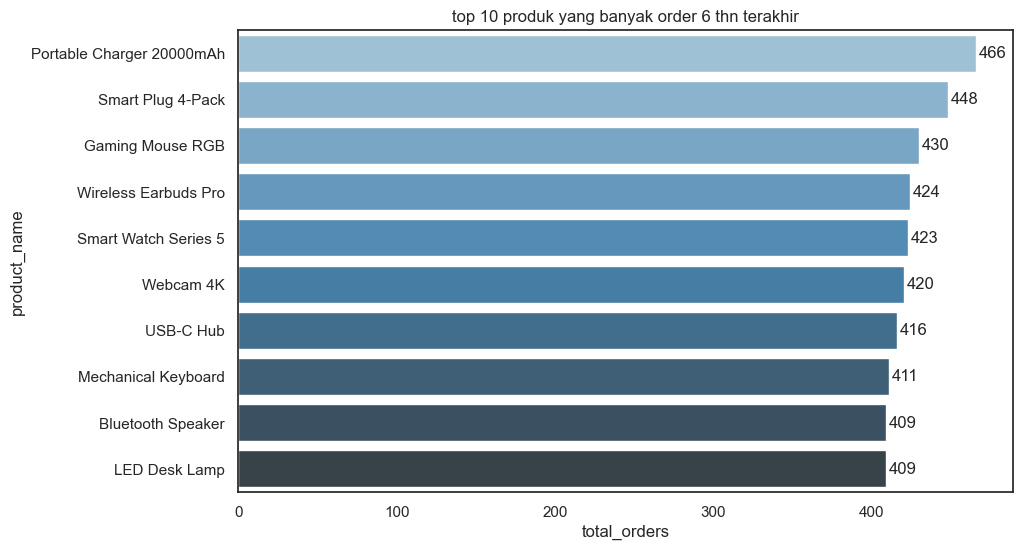

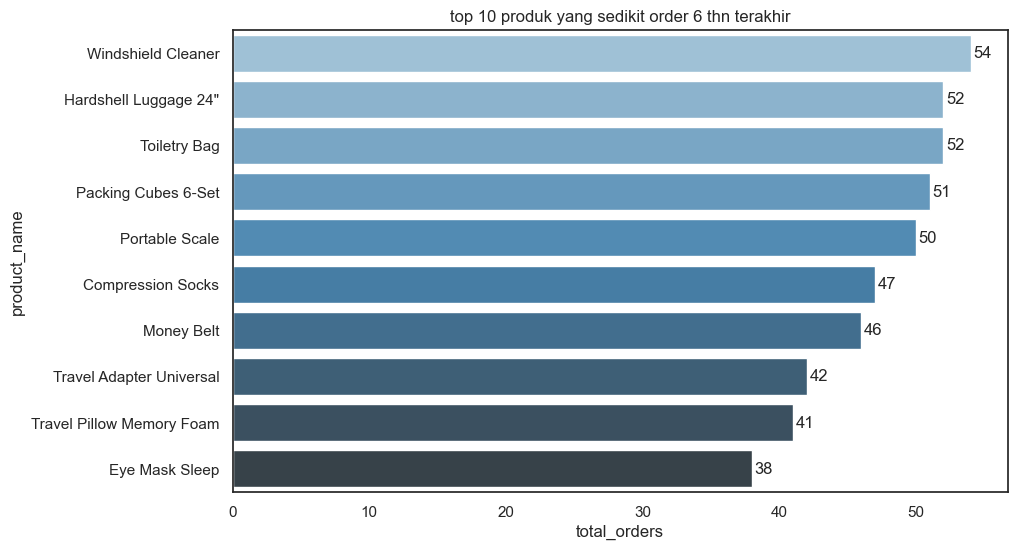

In [27]:
top_products = df_prod.sort_values('total_orders', ascending=False).head(10)
tail_products = df_prod.sort_values('total_orders', ascending=False).tail(10)
ls=[top_products,tail_products]
judul=['top 10 produk yang banyak order','top 10 produk yang sedikit order']
for i in range(len(ls)):
    plt.figure(figsize=(10, 6))
    sns.set_theme(style="white")
    ax = sns.barplot(data=ls[i],x='total_orders',y='product_name',palette='Blues_d')
    for containers in ax.containers:
        ax.bar_label(containers,padding=2)

    plt.title(f'{judul[i]} 6 thn terakhir')

C:\Users\HP\AppData\Local\Temp\ipykernel_5068\2062273218.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=ls[l], x='total_revenue_usd', y='product_name', palette='Greens_d')
C:\Users\HP\AppData\Local\Temp\ipykernel_5068\2062273218.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=ls[l], x='total_revenue_usd', y='product_name', palette='Greens_d')


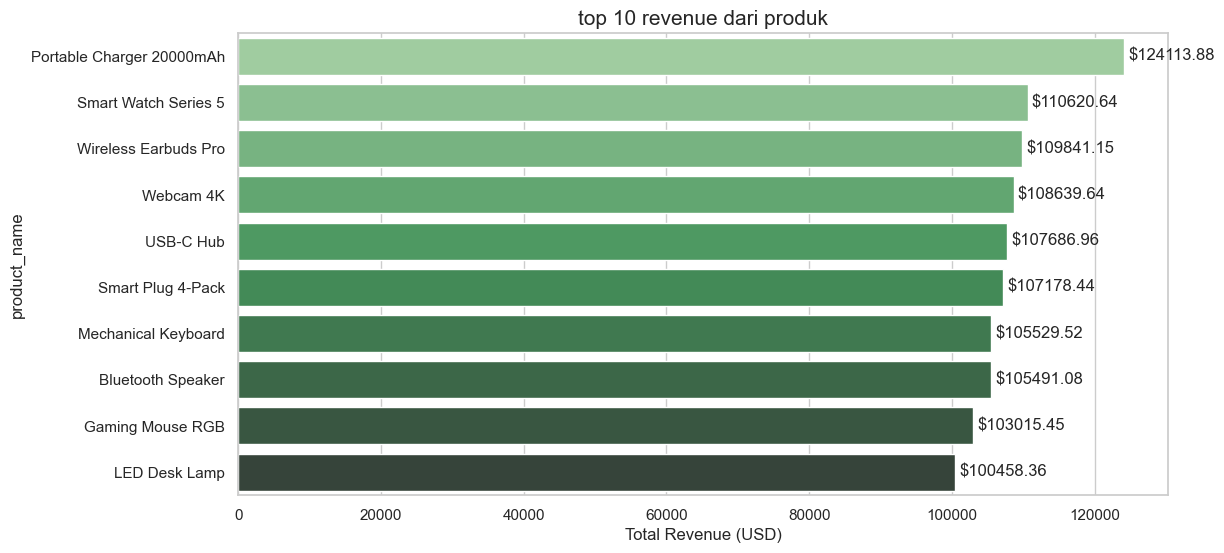

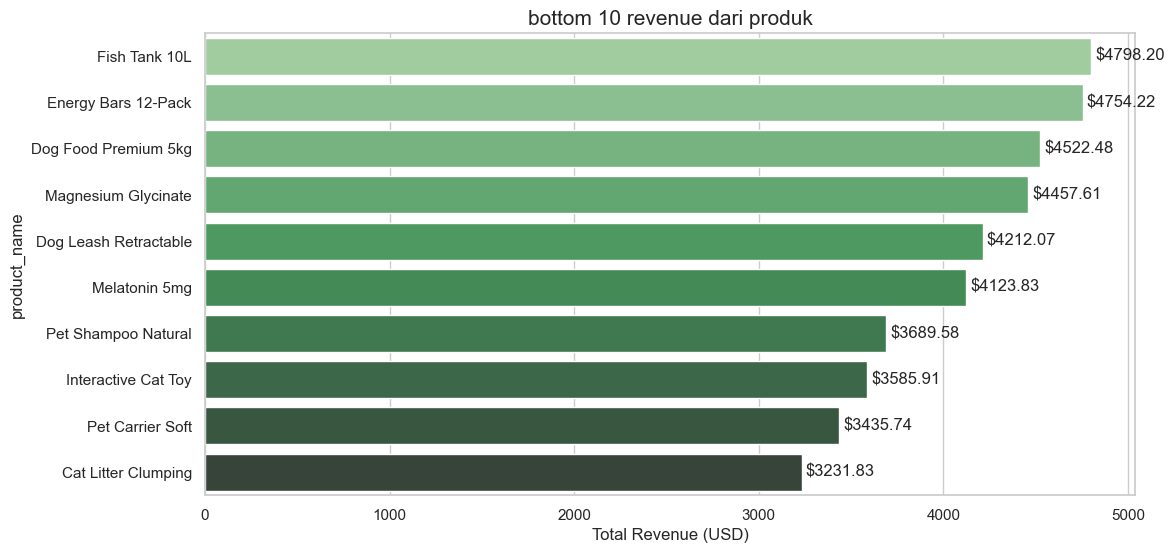

In [28]:
top_revenue = df_prod.sort_values('total_revenue_usd', ascending=False).head(10)
tail_revenue = df_prod.sort_values('total_revenue_usd', ascending=False).tail(10)
ls=[top_revenue,tail_revenue]
judul=['top 10 revenue dari produk','bottom 10 revenue dari produk']

for l in range(len(ls)):
    plt.figure(figsize=(12, 6))
    sns.set_theme(style="whitegrid")

    ax = sns.barplot(data=ls[l], x='total_revenue_usd', y='product_name', palette='Greens_d')

    for i in ax.containers:
        ax.bar_label(i, fmt='$%.2f', padding=3)

    plt.title(judul[l], fontsize=15)
    plt.xlabel('Total Revenue (USD)');

C:\Users\HP\AppData\Local\Temp\ipykernel_5068\3319470220.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['{:,.0f}K'.format(x/1000) for x in ticks])


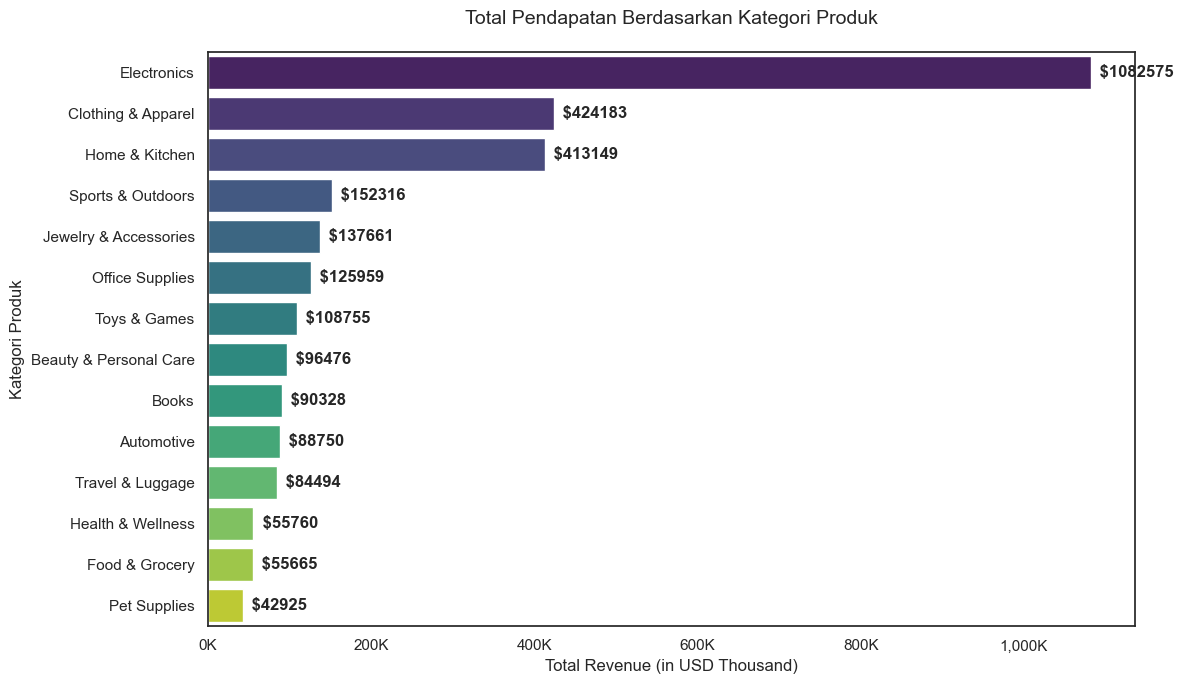

In [29]:
df_cat_rev = df_prod.groupby('category')['total_revenue_usd'].sum().sort_values(ascending=False).reset_index()


plt.figure(figsize=(12, 7))
sns.set_theme(style="white")

ax = sns.barplot(
    data=df_cat_rev, 
    x='total_revenue_usd', 
    y='category', 
    hue='category', 
    palette='viridis',
    legend=False)
for container in ax.containers:
    ax.bar_label(container, fmt=' $%.0f', padding=3, fontweight='bold')

plt.title('Total Pendapatan Berdasarkan Kategori Produk', fontsize=14, pad=20)
plt.xlabel('Total Revenue (USD)')
plt.ylabel('Kategori Produk')


plt.tight_layout()
ticks = ax.get_xticks()
ax.set_xticklabels(['{:,.0f}K'.format(x/1000) for x in ticks])
plt.xlabel('Total Revenue (in USD Thousand)');


Dominasi Electronics: Kategori ini menjadi "tulang punggung" dengan pendapatan tembus ($1,08 Juta). 
Produk seperti Portable Charger dan Smart Watch adalah Produk yang memiliki volume order tinggi sekaligus kontributor revenue terbesar.

Kategori Electronics menyumbang $1.082.575, yang setara dengan hampir 40% dari total pendapatan seluruh kategori.Ada kesenjangan yang sangat jauh antara Electronics dengan peringkat kedua (Clothing) yang hanya di angka $424rb. Ini menunjukkan bisnis ini memiliki spesialisasi yang sangat kuat, namun juga risiko ketergantungan yang tinggi pada satu sektor.

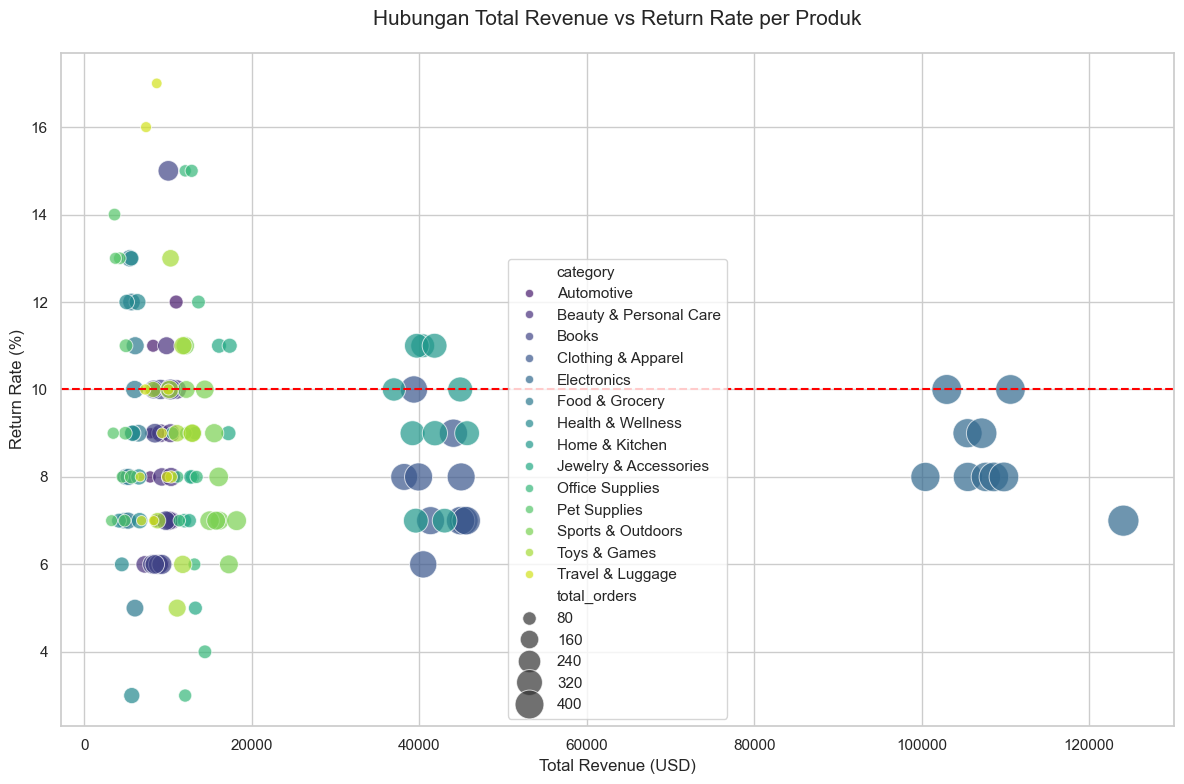

In [30]:
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

sns.scatterplot(
    data=df_prod, 
    x='total_revenue_usd', 
    y='return_rate', 
    size='total_orders', 
    hue='category', 
    sizes=(50, 500), 
    alpha=0.7,
    palette='viridis'
)

plt.axhline(10, color='red', linestyle='--', label='High Return Threshold (10%)')

plt.title('Hubungan Total Revenue vs Return Rate per Produk', fontsize=15, pad=20)
plt.xlabel('Total Revenue (USD)', fontsize=12)
plt.ylabel('Return Rate (%)', fontsize=12)

plt.tight_layout();


1. Kuadran Keberuntungan (Kanan Bawah): "The Cash Cows"Insight: Perhatikan titik-titik biru besar di sisi paling kanan. Ini adalah produk Electronics.Produk-produk ini memiliki Revenue tinggi (> $100k) tetapi Return Rate rendah (di bawah 10%).
Ini adalah skenario ideal dalam bisnis: barang sangat laku, menyumbang uang banyak, dan jarang dikembalikan pelanggan.

2. Kuadran Bahaya (Kiri Atas): "The Profit Killers"  Titik-titik kecil di area kiri atas memiliki Return Rate sangat tinggi (14% - 17%), padahal pendapatannya rendah (di bawah $20k). Ini didominasi kategori Travel & Luggage dan Automotive. Secara statistik, produk-produk ini "beracun". Biaya operasional untuk menangani retur (logistik, admin, pengecekan barang) kemungkinan besar lebih besar daripada keuntungan yang mereka hasilkan. Kategori ini perlu diaudit ulang kualitas produknya.

4. Meskipun Automotive dan Travel & Luggage berada di papan bawah (berdasarkan total pendapatan per kategori:$84k - $88k), produk di dalamnya memiliki Return Rate tinggi (hingga 16%).Perlu diperhatikan biaya operasional yang dikeluarkan untuk menangani retur di kategori ini mungkin tidak sebanding dengan pendapatan kecil yang dihasilkan.

untuk saat ini dapat disimpulkan bahwa bisnis e-commerce ini sangat sehat di kategori utama (Electronics) namun memiliki inefisiensi di kategori pendukung.
1. Didominasi oleh gen z dan milenial dan produk seperti(Gaming Mouse, Wireless Earbuds, Mechanical Keyboard) laku. Hal ini berbanding lurus dengan tren dunia saat ini dimana digitalisasi gaya hidup yang masif
2. Basis Pelanggan(loyal)
Memiliki basis pelanggan "Whales" (pembelanja besar) yang setia, terlihat dari AOV yang terus naik dan dominasi member Platinum/Gold dalam pengeluaran.Kelemahan: Terlalu bergantung pada Electronics. Kategori lain seperti Pet Supplies atau Food masih sangat kecil dan beberapa produk otomotif/travel memiliki risiko retur yang mengkhawatirkan.
3. Bisnis di sektor e-commerce ini mulai stabil hal itu dapat dilihat di tahun 2025-2026(q1), karena adopsi digitalisasi itu sendiri